In [1]:
# loading packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss

In [2]:
# machine learning
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import PolynomialFeatures , MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, BayesianRidge 
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  , mean_absolute_percentage_error
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA
from sklearn.utils import shuffle
from sklearn.cluster import KMeans


import xgboost as xgb

In [3]:
df_original = pd.read_csv("C:\\Github\\Coral_Bleaching_Predictor\\Data\\dataset.csv" , na_values=['nd']) # old data
df_original

,ID,Latitude_Degrees,Longitude_Degrees,Ocean,Realm,Ecoregion,Country_Name,State_Island_Province,City_Town,City_Town_2,...,TSA_Maximum,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean
0,97,-20.899833,149.407722,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Keswick Island,NaN,...,2.40,-3.26,3.0,1.95,7.0,1.0,3.52,1.36,8.43,0.52
1,98,-20.893056,149.421000,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Keswick Island,NaN,...,2.40,-3.26,3.0,1.95,7.0,1.0,3.52,1.36,8.43,0.52
2,116,-20.745806,149.472056,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Wigton Island,Wigton Island Reef,...,2.34,-3.06,1.0,1.47,5.0,1.0,1.51,1.23,7.32,0.49
3,117,-20.737694,149.464944,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Wigton Island,Wigton Island Reef,...,2.64,-3.01,2.0,1.31,5.0,1.0,2.36,0.97,6.86,0.36
4,142,-20.259361,148.814583,Pacific,Central Indo-Pacific,Central and northern Great Barrier Reef,Australia,Queensland,Mount Rooper,Daydream Island,...,2.81,-3.23,4.0,1.72,7.0,1.0,0.00,1.47,9.84,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9660,13073,13.935889,48.386417,Red Sea,Western Indo-Pacific,Gulf of Aden,Yemen,Shabwah Governorate,Bi'r Ali,Eemad,...,10.59,-1.86,1.0,2.30,11.0,2.0,2.63,2.57,20.95,1.08
9661,13074,13.935889,48.386417,Red Sea,Western Indo-Pacific,Gulf of Aden,Yemen,Shabwah Governorate,Bi'r Ali,Eemad,...,10.59,-1.86,1.0,2.30,11.0,2.0,2.63,2.57,20.95,1.08
9662,13075,14.817722,50.015250,Red Sea,Western Indo-Pacific,Gulf of Aden,Yemen,Hadhramaut Governorate,Al-Qurn,Eemad,...,10.51,-2.13,0.0,1.97,10.0,2.0,0.00,2.74,23.70,1.09
9663,13076,15.701611,42.391806,Red Sea,Western Indo-Pacific,South Red Sea,Yemen,Al Hudaydah Governorate,Jazirat Antufash,Seaem,...,2.52,-2.69,0.0,1.63,6.0,1.0,0.00,1.33,8.30,0.54


In [4]:
print(f"total number of rows and columns in the dataset: {len(df_original.columns)} columns, {len(df_original)} rows")

total number of rows and columns in the dataset: 48 columns, 9665 rows


In [5]:
## Grouping years into decodes
def Cleaning_date_to_year(df):
    #Changing date to year
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Year'] = df['Date'].dt.year # New columns with only year 
    
    year_counts = df.groupby(['Year']).size()
    print(year_counts)
    

    return df

df_Makedatetime = Cleaning_date_to_year(df_original)

Year
1998      5
2000      2
2001      3
2002     63
2003    599
2004    731
2005    700
2006    850
2007    643
2008    692
2009    721
2010    538
2011    533
2012    563
2013    626
2014    600
2015    615
2016    619
2017    562
dtype: int64


In [6]:
#Check NAN Data and by what percentage
def nan_check(data):
    total = data.isnull().sum().sort_values(ascending=False)
    percent_1 = data.isnull().sum()/data.isnull().count()*100
    percent_2 = (np.round(percent_1, 1)).sort_values(ascending=False)
    missing_data = pd.concat([total, percent_2], axis=1, keys=['Total', '%'])
    return missing_data

Missing  = nan_check(df_Makedatetime)

In [7]:
def Columns_percent_missing(df,df_dtype, col):
    
    count_less = 0
    count_more = 0
    Index_more = []
    Index_less = []
    for_drop = []
    type_object = []
    type_number = []
    for idx, value in df[col].items():
        if value >= 0.4:
            count_more += 1
            Index_more.append(idx)
            for_drop.append(idx)
        elif value < 0.4:
            count_less += 1
            Index_less.append(idx)
            
    for i in df_dtype.columns:
        if df_dtype[i].dtype == 'object':
            type_object.append(i)
        else:
            type_number.append(i)

    print("\n")
    print(f"more than 0.4% : {count_more}")
    print(f"less than 0.4% : {count_less}")
    print(f"Index_more : {len(Index_more)} attribuue : {Index_more}")
    print(f"Index_less : {len(Index_less)} attribuue : {Index_less}")
    print(f"for_drop : {len(for_drop)} attribuue : {for_drop}")
    print(f"object type : {len(type_object)} attribue : {type_object}")
    print(f"number type : {len(type_number)} attribue : {type_number}")

    return for_drop , type_object
    
columns_drop, col_object = Columns_percent_missing(Missing, df_original, '%')
print("Missing values more than 0.4% : Delete")



more than 0.4% : 4
less than 0.4% : 45
Index_more : 4 attribuue : ['City_Town_3', 'City_Town_2', 'City_Town', 'State_Island_Province']
Index_less : 45 attribuue : ['SSTA_Minimum', 'SSTA_FrequencyMax', 'SSTA_Standard_Deviation', 'TSA_Maximum', 'SSTA_Maximum', 'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation', 'SSTA_Mean', 'SSTA_FrequencyMean', 'Temperature_Kelvin_Standard_Deviation', 'SSTA_DHW', 'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA', 'SSTA', 'Temperature_Minimum', 'Temperature_Maximum', 'TSA_Minimum', 'Temperature_Mean', 'Temperature_Kelvin', 'TSA_Mean', 'TSA_Frequency', 'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax', 'TSA_FrequencyMean', 'TSA_DHW', 'TSA_DHW_Standard_Deviation', 'TSA_DHWMax', 'TSA_DHWMean', 'TSA_Standard_Deviation', 'Windspeed', 'ClimSST', 'ID', 'Latitude_Degrees', 'Average_Bleaching', 'Depth', 'Date2', 'Date', 'Country_Name', 'Ecoregion', 'Realm', 'Ocean', 'Longitude_Degrees', 'Year']
for_drop : 4 attribuue : ['City_Town_3', 

In [8]:
def Clean_data_paper(df, col_object, col_dont_need):
    
    # using data from 2003 to 2020
    df = df[df['Year'] > 2002]

    # Taking only SSTA > 0
    df['SSTA'] = pd.to_numeric(df['SSTA'], errors='coerce') # แปลง ค่าของ SSTA เป็นตัวเลข เเละจัดการกับค่าที่ไม่สามารถเเปลงได้ด้วยการใช้ 'coerce' ซึ่งจะทำให้ค่าที่แปลงไม่ได้กลายเป็น NaN
    df = df[df['SSTA'] > 0] # เลือกเฉพาะคที่มีค่า SSTA มากกว่า 0 เเละ NaN จะถูกละทิ้งไปโดยอัตโนมัติ
    
    df_object = df.drop(columns=col_object) # ลบคอลัมน์ที่เป็น Object ออกเเละค่าที่ไม่จำเป็นออกไป
    df_dont_need = df_object.drop(columns=col_dont_need) # ลบคอลัมน์ที่ไม่จำเป็นออกไป

    df = df_dont_need.rename(columns={"Depth": "Depth_m", "Average_Bleaching": "Percent_Bleaching"}) # เปลี่ยนชื่อคอลัมน์ให้สั้นลง เเละเจข้าใจง่ายขึ้น

    #Transforming column datatypes
    df['ClimSST'] = pd.to_numeric(df['ClimSST'],errors='coerce')
    df['Percent_Bleaching'] = pd.to_numeric(df['Percent_Bleaching'],errors='coerce')
    
    return df

col_dont_need = ['ID', 'Date', 'Date2', 'Year' , 'SSTA_Mean']
df_Clean_already = Clean_data_paper(df_Makedatetime, col_object, col_dont_need)
df_Clean_already = df_Clean_already.fillna(method='ffill')

print(f"total number of rows and columns in the dataset: {len(df_Clean_already.columns)} columns, {len(df_Clean_already)} rows")
print("มีการเพิ่มคอลัมน์ Year ขึ้นมาเพื่อนำมาใช้ในการจัดกลุ่มข้อมูลตามปี")

total number of rows and columns in the dataset: 36 columns, 6112 rows
มีการเพิ่มคอลัมน์ Year ขึ้นมาเพื่อนำมาใช้ในการจัดกลุ่มข้อมูลตามปี


C:\Users\superuser\AppData\Local\Temp\ipykernel_22572\3032694163.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['SSTA'] = pd.to_numeric(df['SSTA'], errors='coerce') # แปลง ค่าของ SSTA เป็นตัวเลข เเละจัดการกับค่าที่ไม่สามารถเเปลงได้ด้วยการใช้ 'coerce' ซึ่งจะทำให้ค่าที่แปลงไม่ได้กลายเป็น NaN
C:\Users\superuser\AppData\Local\Temp\ipykernel_22572\3032694163.py:23: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_Clean_already = df_Clean_already.fillna(method='ffill')


In [9]:
df_Clean_already

,Latitude_Degrees,Longitude_Degrees,Depth_m,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,...,TSA_Maximum,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean
0,-20.899833,149.407722,4.0,6.25,297.78,301.670,298.17,291.910000,303.850,2.740,...,2.400000,-3.260,3.0,1.950,7.000000,1.0,3.52,1.360000,8.43,0.520000
1,-20.893056,149.421000,5.0,8.75,297.78,301.670,298.17,291.910000,303.850,2.740,...,2.400000,-3.260,3.0,1.950,7.000000,1.0,3.52,1.360000,8.43,0.520000
2,-20.745806,149.472056,6.0,11.25,298.17,301.380,298.34,292.670000,303.760,2.570,...,2.340000,-3.060,1.0,1.470,5.000000,1.0,1.51,1.230000,7.32,0.490000
3,-20.737694,149.464944,5.0,25.00,298.21,301.560,298.37,292.010000,304.040,2.520,...,2.640000,-3.010,2.0,1.310,5.000000,1.0,2.36,0.970000,6.86,0.360000
4,-20.259361,148.814583,2.0,1.00,296.48,296.380,298.47,291.830000,304.540,2.700,...,2.810000,-3.230,4.0,1.720,7.000000,1.0,0.00,1.470000,9.84,0.560000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9641,20.738889,107.058333,3.2,0.00,262.15,302.955,298.07,288.423333,306.535,4.495,...,3.193333,-5.255,0.0,1.645,7.333333,1.0,0.00,1.381667,11.57,0.446667
9646,20.845833,107.177778,3.0,0.00,299.80,302.300,298.09,289.690000,307.260,4.360,...,4.070000,-5.080,0.0,2.180,11.000000,1.0,0.00,1.740000,12.00,0.640000
9649,12.601722,53.817306,6.0,0.00,301.40,302.670,299.38,294.550000,309.550,1.980,...,6.920000,-3.240,0.0,1.400,6.000000,0.0,0.00,1.710000,19.41,0.370000
9663,15.701611,42.391806,9.0,0.00,304.39,303.890,301.97,296.610000,307.200,2.400,...,2.520000,-2.690,0.0,1.630,6.000000,1.0,0.00,1.330000,8.30,0.540000


In [10]:
def Divide_area(df):
    
    Topical_zone = df[
    (df['Latitude_Degrees'] > -23.5) &
    (df['Latitude_Degrees'] < 23.5)
    ]

    Other_zone = df[
        (df['Latitude_Degrees'] <= -23.5) | 
        (df['Latitude_Degrees'] >= 23.5)
    ]
    
    return Topical_zone , Other_zone

Topical , Other = Divide_area(df_Clean_already)
print(f"zone hot climate: {len(Topical)}")
print(f"zone else: {len(Other)}")


zone hot climate: 5267
zone else: 845


In [11]:
def Histrogram_data(df,col):
    plt.hist(df[[col]], density=True, bins=30, color='skyblue', edgecolor='black')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.title(f'Histrogram of {col}')
    plt.show()
    
    High = []
    Low = []
    zero = 0
    
    for i in df[col]:
        if i == 0:
            text = "Data not values"
            zero += 1
        elif i >= 30:
            High.append(i)
        else:
            Low.append(i)
            
    print(f"columns have dataset : {len(df[col])}")
    print(f"columns have zero percent data : {zero}")
    print(f"columns have maximum data : {len(High)} from more than >30%")
    print(f"columns have minimum data : {len(Low)} from less than <30%")
    print(f"ALL Dataset ; {zero + len(High) + len(Low)}")
        
        

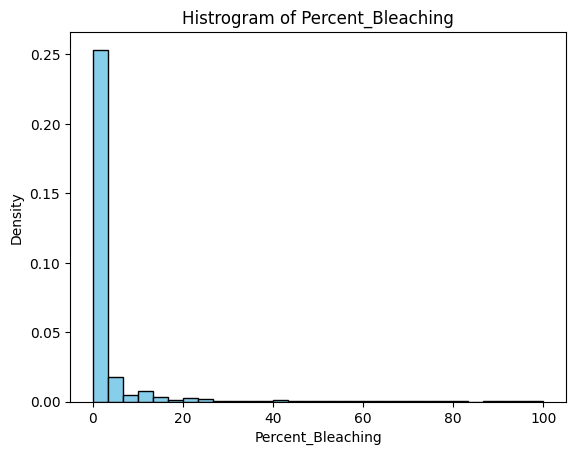

columns have dataset : 5267
columns have zero percent data : 3330
columns have maximum data : 136 from more than >30%
columns have minimum data : 1801 from less than <30%
ALL Dataset ; 5267


In [12]:
Histrogram_data(Topical,'Percent_Bleaching')

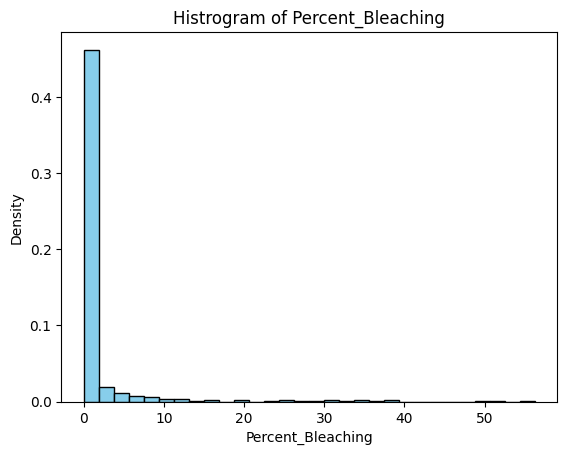

columns have dataset : 845
columns have zero percent data : 584
columns have maximum data : 15 from more than >30%
columns have minimum data : 246 from less than <30%
ALL Dataset ; 845


In [13]:
Histrogram_data(Other,'Percent_Bleaching')

In [14]:
def Zoom_zero(df):
    # กรองเฉพาะจุดที่รอดชีวิต (0%)
    zoom_zero = df[df['Percent_Bleaching'] == 0]
    
    # ใช้ ['Column'] แทน [['Column']] เพื่อให้ออกมาเป็นตัวเลขเดี่ยวๆ แล้วใช้ .mean()
    print(f"SSTA      : {zoom_zero['SSTA'].mean():.4f}")
    print(f"SSTA_DHW  : {zoom_zero['SSTA_DHW'].mean():.4f}")
    print(f"TSA_DHW   : {zoom_zero['TSA_DHW'].mean():.4f}")
    print(f"Depth_m   : {zoom_zero['Depth_m'].mean():.4f}")
    print(f"Temperature_Maximum  : {zoom_zero['Temperature_Maximum'].mean():.4f}")
    print("======================================================")

In [15]:
Other[['SSTA_Frequency']]

,SSTA_Frequency
85,15.00
86,17.00
87,14.00
88,17.00
89,14.00
...,...
9353,5.00
9354,7.00
9355,7.00
9356,5.25


In [16]:
def Zoom_zero_compare(df_tropical, df_other):
    # กำหนดตัวแปรที่อยากส่อง (เช็คให้ชัวร์ว่าชื่อคอลัมน์ตรงกับในข้อมูลจริงนะครับ)
    cols_to_look = ['SSTA_DHW', 'TSA_DHW', 'ClimSST', 'Temperature_Kelvin', 'Windspeed', 'Depth_m']
    
    # กรองเอาเฉพาะที่รอดชีวิต (0%) ของทั้ง 2 โซน
    zero_trop = df_tropical[df_tropical['Percent_Bleaching'] == 0][cols_to_look]
    zero_other = df_other[df_other['Percent_Bleaching'] == 0][cols_to_look]
    
    # คำนวณสถิติ
    stat_trop = zero_trop.agg(['mean', 'max', 'std']).T
    stat_other = zero_other.agg(['mean', 'max', 'std']).T
    
    print("=== 🌴 สถิติพื้นที่รอดชีวิต (0%) : โซน TROPICAL ===")
    display(stat_trop.round(3))
    
    print("\n=== 🌊 สถิติพื้นที่รอดชีวิต (0%) : โซน OTHER ===")
    display(stat_other.round(3))

# ---------------------------------------------------------
# วิธีใช้งาน: โยนทั้งสองตารางเข้าไปพร้อมกันเลยครับ
# Zoom_zero_compare(Tropical, Other) 
# (เปลี่ยนชื่อ Tropical และ Other ให้ตรงกับชื่อตัวแปร DataFrame ของคุณนะครับ)

In [17]:
Zoom_zero_compare(Topical, Other)

=== 🌴 สถิติพื้นที่รอดชีวิต (0%) : โซน TROPICAL ===


,mean,max,std
SSTA_DHW,2.624,37.45,3.324
TSA_DHW,0.791,36.31,2.198
ClimSST,293.993,304.39,15.385
Temperature_Kelvin,302.016,305.85,1.617
Windspeed,4.303,14.00,2.127
Depth_m,6.191,23.00,3.453



=== 🌊 สถิติพื้นที่รอดชีวิต (0%) : โซน OTHER ===


,mean,max,std
SSTA_DHW,4.600,24.320,4.790
TSA_DHW,1.327,17.095,2.836
ClimSST,287.346,303.670,17.014
Temperature_Kelvin,299.475,305.600,2.622
Windspeed,4.971,13.000,1.779
Depth_m,6.902,15.000,2.869
